# 09 — Augmentacja klas rzadkich: ablacja (klasyczny)

Każdy warunek: char-TF-IDF dopasowany na *tym* zbiorze treningowym, LogReg, progi na val.

1. `baseline` — `class_weight=None`
2. `reweight` — `class_weight=balanced`
3. `oversample` — duplikacja wierszy z rzadką etykietą
4. `back-translation` — + parafrazy NLLB
5. `llm` — + przykłady generowane przez Bielik-11B

Klasy rzadkie: strach, zaufanie, smutek. Test nietknięty.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, recall_score
from thesis_lib import optimal_thresholds as opt_thresholds, bootstrap_f1_ci
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid"); plt.rcParams["savefig.dpi"]=300

EMOTIONS=["radość","smutek","zaufanie","wstręt","strach","gniew","przeczuwanie","zdziwienie"]
RARE=["strach","zaufanie","smutek"]; RANDOM_STATE=42
PROCESSED_DIR=Path("../data/processed"); RESULTS_DIR=Path("../data/results"); FIGURES_DIR=Path("../figures")

tw_train=pd.read_csv(PROCESSED_DIR/"twitteremo_train.csv"); tw_val=pd.read_csv(PROCESSED_DIR/"twitteremo_val.csv")
tw_test=pd.read_csv(PROCESSED_DIR/"twitteremo_test.csv")
for d in (tw_train,tw_val,tw_test): d["tekst"]=d["tekst"].fillna("")
y_val,y_test=tw_val[EMOTIONS].values,tw_test[EMOTIONS].values
print("train:",len(tw_train))

train: 28684


In [2]:
def train_eval(train_df, class_weight):
    vec=TfidfVectorizer(max_features=50_000,ngram_range=(3,5),analyzer="char_wb",min_df=3,sublinear_tf=True,lowercase=True)
    Xtr=vec.fit_transform(train_df["tekst"].fillna("")); ytr=train_df[EMOTIONS].values
    Xva=vec.transform(tw_val["tekst"]); Xte=vec.transform(tw_test["tekst"])
    clf=OneVsRestClassifier(LogisticRegression(max_iter=1000,C=1.0,class_weight=class_weight,
            solver="liblinear",random_state=RANDOM_STATE))
    clf.fit(Xtr,ytr)
    thr=opt_thresholds(y_val,clf.predict_proba(Xva))
    pred=(clf.predict_proba(Xte)>=thr).astype(int)
    # bootstrap CI — bez niego różnice rzędu 0,01-0,03 nie dają się uczciwie zinterpretować
    base,lo,hi=bootstrap_f1_ci(y_test,pred)
    row={"f1_macro":base,"ci_low":round(lo,3),"ci_high":round(hi,3),
         "f1_micro":f1_score(y_test,pred,average="micro",zero_division=0),
         "n_train":len(train_df)}
    for c in RARE:
        i=EMOTIONS.index(c)
        row[f"recall_{c}"]=recall_score(y_test[:,i],pred[:,i],zero_division=0)
        row[f"f1_{c}"]=f1_score(y_test[:,i],pred[:,i],zero_division=0)
    # kontrola: średni F1 częstych klas
    freq=[e for e in EMOTIONS if e not in RARE]
    row["f1_frequent_avg"]=np.mean([f1_score(y_test[:,EMOTIONS.index(e)],pred[:,EMOTIONS.index(e)],zero_division=0) for e in freq])
    return row

In [3]:
# warianty zbioru treningowego
rng=np.random.default_rng(RANDOM_STATE)
rare_mask=tw_train[RARE].sum(1)>0
oversampled=pd.concat([tw_train, tw_train[rare_mask], tw_train[rare_mask]], ignore_index=True)  # rzadkie x3

variants=[("1_baseline", tw_train, None),
          ("2_reweight", tw_train, "balanced"),
          ("3_oversample", oversampled, None)]

bt_path=PROCESSED_DIR/"aug_bt_train.csv"
if bt_path.exists():
    bt=pd.read_csv(bt_path); bt["tekst"]=bt["tekst"].fillna("")
    aug_bt=pd.concat([tw_train, bt[["tekst"]+EMOTIONS]], ignore_index=True)
    variants.append(("4_backtranslation", aug_bt, None))
    print(f"BT: +{len(bt)} wierszy")
else:
    print("aug_bt_train.csv brak — pomijam warunek back-translation")

llm_path=PROCESSED_DIR/"aug_llm_train.csv"
if llm_path.exists():
    llm=pd.read_csv(llm_path); llm["tekst"]=llm["tekst"].fillna("")
    aug_llm=pd.concat([tw_train, llm[["tekst"]+EMOTIONS]], ignore_index=True)
    variants.append(("5_llm", aug_llm, None))
    print(f"LLM: +{len(llm)} wierszy")
else:
    print("aug_llm_train.csv brak — pomijam warunek LLM (czeka na Kaggle)")

BT: +3018 wierszy
LLM: +1138 wierszy


In [4]:
rows=[]
for name,df,cw in variants:
    print(f"  {name} (n_train={len(df)}, class_weight={cw}) ...", flush=True)
    r=train_eval(df,cw); r["warunek"]=name; rows.append(r)
res=pd.DataFrame(rows)[["warunek","n_train","f1_macro","ci_low","ci_high","f1_micro","f1_frequent_avg",
        "recall_strach","recall_zaufanie","recall_smutek","f1_strach","f1_zaufanie","f1_smutek"]]
res.to_csv(RESULTS_DIR/"aug_classical_ablation.csv",index=False)
display(res.round(3))

  1_baseline (n_train=28684, class_weight=None) ...


  2_reweight (n_train=28684, class_weight=balanced) ...


  3_oversample (n_train=34204, class_weight=None) ...


  4_backtranslation (n_train=31702, class_weight=None) ...


  5_llm (n_train=29822, class_weight=None) ...


,warunek,n_train,f1_macro,ci_low,ci_high,f1_micro,f1_frequent_avg,recall_strach,recall_zaufanie,recall_smutek,f1_strach,f1_zaufanie,f1_smutek
0,1_baseline,28684,0.441,0.403,0.477,0.574,0.552,0.077,0.344,0.388,0.143,0.273,0.349
1,2_reweight,28684,0.474,0.436,0.510,0.579,0.554,0.385,0.281,0.388,0.385,0.269,0.366
2,3_oversample,34204,0.461,0.424,0.495,0.572,0.545,0.385,0.250,0.448,0.345,0.244,0.368
3,4_backtranslation,31702,0.456,0.417,0.495,0.580,0.556,0.308,0.266,0.358,0.296,0.258,0.316
4,5_llm,29822,0.456,0.411,0.494,0.575,0.548,0.231,0.234,0.343,0.333,0.238,0.333


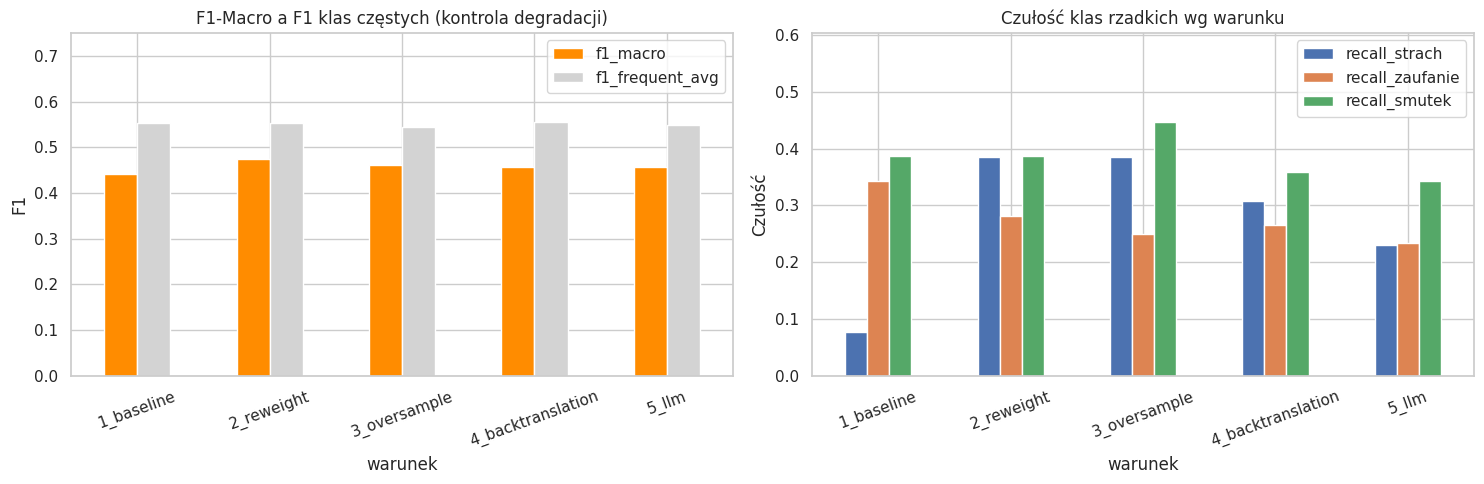

In [5]:
# z pliku aug_classical_ablation.csv — dzięki temu da się poprawić styl bez
# ponownego trenowania. Tutaj zostaje wersja podglądowa.
fig,ax=plt.subplots(1,2,figsize=(15,5))
b=res.set_index("warunek")
b[["f1_macro","f1_frequent_avg"]].plot(kind="bar",ax=ax[0],color=["darkorange","lightgray"])
ax[0].set_title("F1-Macro a F1 klas częstych (kontrola degradacji)"); ax[0].set_ylabel("F1")
ax[0].set_ylim(0,b[["f1_macro","f1_frequent_avg"]].to_numpy().max()*1.35); ax[0].tick_params(axis='x',rotation=20)
b[["recall_strach","recall_zaufanie","recall_smutek"]].plot(kind="bar",ax=ax[1])
ax[1].set_title("Czułość klas rzadkich wg warunku"); ax[1].set_ylabel("Czułość")
ax[1].set_ylim(0,b[["recall_strach","recall_zaufanie","recall_smutek"]].to_numpy().max()*1.35); ax[1].tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.show()